In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('cars.csv')

In [4]:
df.sample(5)

,brand,km_driven,fuel,owner,selling_price
477,Ford,60000,Diesel,Second Owner,300000
5161,Maruti,60000,Diesel,First Owner,500000
6629,Mahindra,80000,Diesel,First Owner,722000
3571,Mahindra,80000,Diesel,First Owner,660000
5766,Hyundai,25000,Petrol,First Owner,310000


In [5]:
df.isnull().sum()

,0
brand,0
km_driven,0
fuel,0
owner,0
selling_price,0


In [110]:
df['fuel'].value_counts()
df['owner'].value_counts()

,count
owner,
First Owner,5289
Second Owner,2105
Third Owner,555
Fourth & Above Owner,174
Test Drive Car,5


In [111]:
from sklearn.model_selection import train_test_split

In [194]:
x_train, x_test ,y_train , y_test = train_test_split(df.drop('selling_price' ,axis=1), df['selling_price'] ,test_size=0.2 , random_state=0 )

In [195]:
x_train.shape


(6502, 4)

In [207]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
y_train_scale = scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_scale = scaler.transform(y_test.values.reshape(-1,1))

In [208]:
from sklearn.preprocessing import OneHotEncoder

In [209]:
ohe = OneHotEncoder( drop = 'first' , sparse_output=False)

In [210]:
x_train_encoding = ohe.fit_transform(x_train[['fuel', 'owner']])
x_test_encoding = ohe.transform(x_test[['fuel' ,'owner']])

In [211]:
counts = df['brand'].value_counts()

In [212]:
threshold= 100
repl = counts[counts <= threshold]

In [213]:
df['brand'] = df['brand'].replace(repl.index , 'unknown')

In [214]:
x_train_brand = ohe.fit_transform(x_train[['brand']])
x_test_brand = ohe.transform(x_test[['brand']])

In [215]:
x_train_km_driven = x_train.drop(columns=['fuel' ,'owner' ,'brand']).values
x_test_km_driven = x_test.drop(columns=['fuel' ,'owner' ,'brand']).values


In [216]:
import numpy as np

In [217]:
x_train_transform  = np.concatenate((x_train_encoding , x_train_brand , x_train_km_driven) , axis=1)

x_test_transform = np.concatenate((x_test_encoding , x_test_brand , x_test_km_driven) , axis=1)

In [218]:
import seaborn as sns

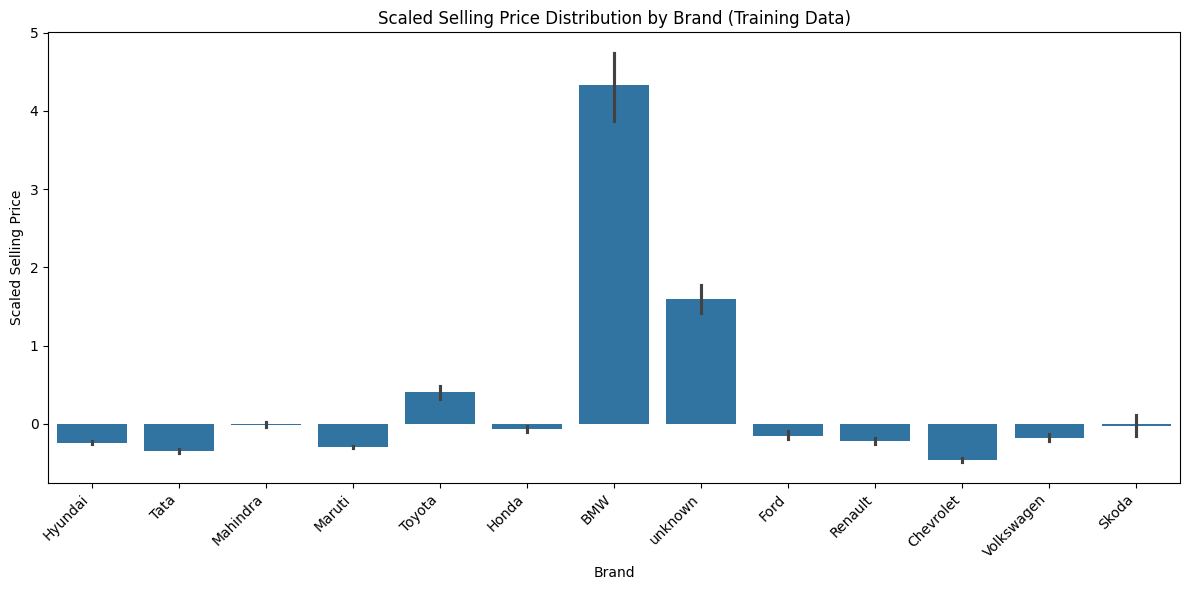

In [230]:
plt.figure(figsize=(12, 6))

# Create a temporary DataFrame for plotting aligned with the training data
plot_df = pd.DataFrame({'brand': x_train['brand'], 'scaled_selling_price': y_train_scale.flatten()})

sns.barplot(x='brand', y='scaled_selling_price', data=plot_df)
plt.xticks(rotation=45, ha='right')
plt.title('Scaled Selling Price Distribution by Brand (Training Data)')
plt.xlabel('Brand')
plt.ylabel('Scaled Selling Price')
plt.tight_layout()
plt.show()

In [241]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [242]:
lm = LinearRegression()

In [243]:
clf = lm.fit(x_train_transform , y_train_scale)

In [244]:
y_pred = lm.predict(x_test_transform)

In [245]:
r2_score(y_test_scale, y_pred)

0.5575868104965401